In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import backtestPairs, calculatePairMetrics
# from MODELS.teamInfo import *


In [2]:
import joblib


# Load NGBoost mean and variance models
mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_25.pkl')
variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_25.pkl')
calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_25.pkl')

# mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_26.pkl')
# variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_26.pkl')
# calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_26.pkl')

models = {
    'mean': mean_model,
    'variance': variance_model,
    'calibration_factor': calibration_factor
}

features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

print(f"Loaded NGBoost models with calibration factor: {calibration_factor}")
print(f"Number of features: {len(features)}")

Loaded NGBoost models with calibration factor: 3.97
Number of features: 172


In [3]:
pd.set_option('display.max_columns', None)

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
# s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')
# df = s26
df = s25

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'prizepicks') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)


C:\Users\alexg\AppData\Local\Temp\ipykernel_70384\2718787215.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
17941,17941,17941,17941,Jared McCain,player_points,prizepicks,under,20.5,-137,Philadelphia 76ers,Los Angeles Clippers,51b8fadeddaf0e6dca09d48b50b23c82,2024-11-24T23:10:00Z,2024-11-24,NaN,NaN,NaN,under
212,212,212,212,LeBron James,player_points,prizepicks,over,24.5,-137,Los Angeles Lakers,Minnesota Timberwolves,026ffb7b2ccf8a09dab9b24f33de27f7,2024-10-23T02:00:00Z,2024-10-22,NaN,NaN,NaN,over
58461,58461,58461,58461,Amen Thompson,player_points,prizepicks,under,17.5,-137,New York Knicks,Houston Rockets,NaN,NaN,2025-02-04,game,18.5,100.0,under
116398,116398,116398,15471,Jarred Vanderbilt,player_points,prizepicks,over,4.5,-137,Los Angeles Lakers,New York Knicks,NaN,NaN,2025-03-07,game,4.5,-104.0,over
36389,36389,36389,36389,Mason Plumlee,player_points,prizepicks,under,6.5,-137,Phoenix Suns,Memphis Grizzlies,b9ee2d4806667285e40708d7887b00c8,2025-01-01T02:10:00Z,2024-12-31,NaN,NaN,NaN,under


In [95]:
# backtestData= pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/s26props.csv')
# s26_other = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251106.csv')
# s26_other1 = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251107.csv')
# backtestData = pd.concat([backtestData, s26_other, s26_other1])

# backtestData = backtestData[(backtestData['BOOKMAKER'] == 'Underdog') &  
#                             (backtestData['CATEGORY'] == 'player_points')]
# backtestData.rename(columns={'COMMENCE_TIME': 'GAME_DATE', 'OVER/UNDER': 'SIDE'}, inplace=True)
# backtestData

In [5]:
date = '2024-11-07'

results = backtestPairs(
    data=s25,
    backtestData=backtestData,
    gameDate=date,
    models=models,  
    features=features,
    edge_threshold=0.60, 
    top_n=10, 
    variance_inflation=1.1, 
    use_monte_carlo=True, n_simulations=10000, max_kelly=0.25, stake=10)


# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("PAIR BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['pair_profit'].sum() * 3
    avg_profit = results['pair_profit'].mean() * 3
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

Starting backtest for pairs on 2024-11-07
Time taken for pairs: 3.8549160957336426 seconds
Time taken for sorting: 3.8559162616729736 seconds
Time taken for dropping duplicates: 3.857434034347534 seconds
Time taken for iterating over evData: 3.857434034347534 seconds
Time taken for backtest_results: 3.863960027694702 seconds
PAIR BETTING RESULTS ANALYSIS
Total Bets: 10
Wins: 1
Win Rate: 10.00%
Total Profit: $-210.00
Average Profit per Bet: $-21.00


,NAME 1,NAME 2,LINE 1,LINE 2,PREDICTION 1,PREDICTION 2,MODEL SIDE 1,MODEL SIDE 2,PROB 1,PROB 2,PROB BOTH,EDGE 1,EDGE 2,COMBINED EDGE,EV$,KELLY FULL,RECOMMENDATION,INTERVAL WIDTH 1,INTERVAL WIDTH 2,SIGMA 1,SIGMA 2,SIGMA FLAG 1,SIGMA FLAG 2,EXPECTED ROI,SIMULATION METHOD,actual1,actual2,leg1_won,leg2_won,pair_won,pair_recommendation,pair_profit,selection,date
0,Jaden McDaniels,Lauri Markkanen,10.0,20.0,13.23,15.72,over,under,0.702,0.695,0.4884,0.124,0.117,0.154,4.65,0.233,0,26.67,31.13,6.85,7.94,High,High,46.5,Monte Carlo,19,8,1,1,1,0,20.0,top_ev,2024-11-07
1,Deni Avdija,Jaden McDaniels,10.5,10.0,13.49,13.23,over,over,0.694,0.700,0.4859,0.116,0.122,0.152,4.58,0.229,0,25.35,26.67,6.47,6.85,High,High,45.8,Monte Carlo,9,19,0,1,0,0,-10.0,top_ev,2024-11-07
2,Deni Avdija,Lauri Markkanen,10.5,20.0,13.49,15.72,over,under,0.694,0.695,0.4828,0.116,0.117,0.149,4.48,0.224,0,25.35,31.13,6.47,7.94,High,High,44.8,Monte Carlo,9,8,0,1,0,0,-10.0,top_ev,2024-11-07
3,Jaden McDaniels,Cody Williams,10.0,6.0,13.23,7.55,over,over,0.702,0.667,0.4687,0.124,0.089,0.135,4.06,0.203,0,26.67,18.56,6.85,5.62,High,Med,40.6,Monte Carlo,19,6,1,0,0,0,-10.0,top_ev,2024-11-07
4,Josh Giddey,Jaden McDaniels,13.5,10.0,16.45,13.23,over,over,0.669,0.700,0.4684,0.091,0.122,0.134,4.05,0.203,0,29.78,26.67,7.60,6.85,High,High,40.5,Monte Carlo,9,19,0,1,0,0,-10.0,top_ev,2024-11-07
5,Jaden McDaniels,Walker Kessler,10.0,8.5,13.23,10.62,over,over,0.702,0.663,0.4656,0.124,0.085,0.131,3.97,0.198,0,26.67,21.69,6.85,5.65,High,Med,39.7,Monte Carlo,19,6,1,0,0,0,-10.0,top_ev,2024-11-07
6,Josh Giddey,Lauri Markkanen,13.5,20.0,16.45,15.72,over,under,0.669,0.695,0.4654,0.091,0.117,0.131,3.96,0.198,0,29.78,31.13,7.60,7.94,High,High,39.6,Monte Carlo,9,8,0,1,0,0,-10.0,top_ev,2024-11-07
7,Deni Avdija,Cody Williams,10.5,6.0,13.49,7.55,over,over,0.694,0.667,0.4634,0.116,0.089,0.129,3.90,0.195,0,25.35,18.56,6.47,5.62,High,Med,39.0,Monte Carlo,9,6,0,0,0,0,-10.0,top_ev,2024-11-07
8,Deni Avdija,Walker Kessler,10.5,8.5,13.49,10.62,over,over,0.694,0.663,0.4603,0.116,0.085,0.126,3.81,0.190,0,25.35,21.69,6.47,5.65,High,Med,38.1,Monte Carlo,9,6,0,0,0,0,-10.0,top_ev,2024-11-07
9,Deni Avdija,Josh Giddey,10.5,13.5,13.49,16.45,over,over,0.694,0.660,0.4580,0.116,0.081,0.124,3.74,0.187,0,25.35,29.78,6.47,7.60,High,High,37.4,Monte Carlo,9,9,0,0,0,0,-10.0,top_ev,2024-11-07


## Points

In [6]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(
        data=s25,
        backtestData=backtestData,
        gameDate=date,
        models=models,  
        features=features,
        edge_threshold=0.50, 
        top_n=10, 
        variance_inflation=1.1, 
        use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=10)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-22... 1/163
Starting backtest for pairs on 2024-10-22
Time taken for pairs: 2.8881402015686035 seconds
Time taken for sorting: 2.8881402015686035 seconds
Time taken for dropping duplicates: 2.8906540870666504 seconds
Time taken for iterating over evData: 2.8906540870666504 seconds
Time taken for backtest_results: 2.8971710205078125 seconds
  ✓ Processed 10 bets
Processing 2024-10-23... 2/163
Starting backtest for pairs on 2024-10-23
Time taken for pairs: 11.616159439086914 seconds
Time taken for sorting: 11.6181640625 seconds
Time taken for dropping duplicates: 11.620163679122925 seconds
Time taken for iterating over evData: 11.620163679122925 seconds
Time taken for backtest_results: 11.625183343887329 seconds
  ✓ Processed 10 bets
Processing 2024-10-24... 3/163
Starting backtest for pairs on 2024-10-24
Time taken for pairs: 5.4689857959747314 seconds
Time taken for sorting: 5.469986438751221 seconds
Time taken for dropping duplicates: 5.471993446350098 seconds
Time 

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,361
   Wins: 518
   Hit Rate: 38.06%
   Total Profit: $1,930.00
   Total Staked: $13,610.00
   ROI: 14.18%
   Volatility: $79.68
   Max Drawdown: $-700.00
   Sharpe Ratio: 3.403

   PROBABILITY METRICS:
   Brier Score: 0.2647 (lower is better)
   Log Loss: 0.7263 (lower is better)
   AUC-ROC: 0.6029 (higher is better)
   Samples: 1361

 RECOMMENDED BETS ANALYSIS (Edge > 0.60):
   Total Bets: 20
   Wins: 10
   Hit Rate: 50.00%
   Total Profit: $100.00
   Total Staked: $200.00
   ROI: 50.00%
   Volatility: $57.88
   Max Drawdown: $-30.00
   Sharpe Ratio: 6.602


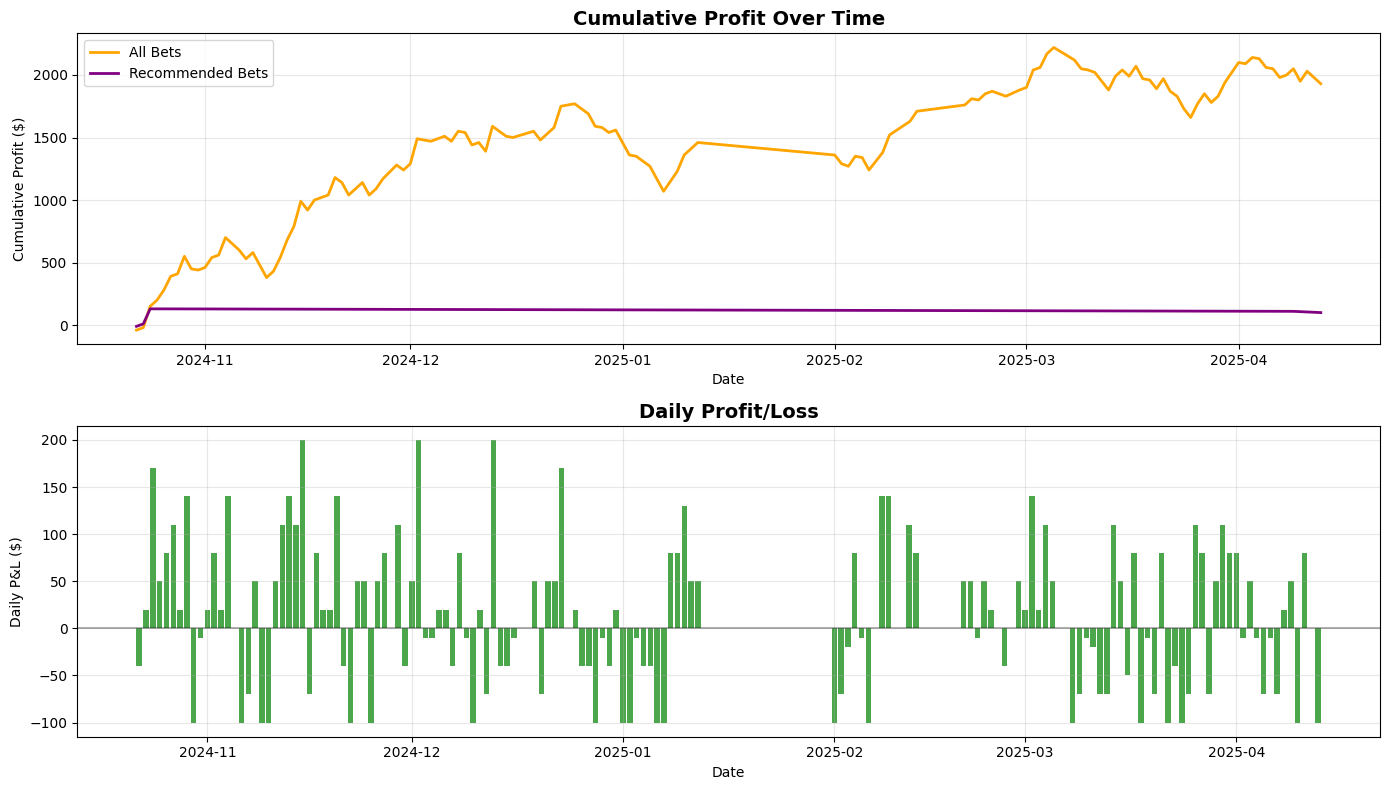

In [7]:
all_metrics = calculatePairMetrics(final_results, stake=10)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=10)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics
    if 'probability_metrics' in all_metrics and 'error' not in all_metrics['probability_metrics']:
        prob_metrics = all_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

if rec_metrics:
    print("\n RECOMMENDED BETS ANALYSIS (Edge > 0.60):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")
    
# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()